# **Imports**

In [1]:

from earthscape.utils.constants import ES_SPLIT_DIR, SMOKE_DIR, SG_MAPPING, STR_VERSION
from earthscape.utils import set_seed
from earthscape.loaders import ESDataset_Classification, get_norm_stats


import os
import glob
import datetime
import pandas as pd
import geopandas as gpd
import torch
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt


# **Setup**

In [2]:
############################################################
# Define Parameters for Dataset & Dataloader
############################################################

##### set seed & device
seed = 111
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


##### setup input feature dict, datasets, & dataloaders...
# define input features dict
input_dict = {
    'multi': {
        'channels': ['dem.tif', 'aerialr.tif', 'aerialg.tif', 'osm.tif']
        }, 
    }


##### setup input features dict...
# path to training split statistics for normalization
norm_stats_path = f"../splits/{STR_VERSION}_splits/train_stats.csv"

# final input features & noramlization stats for each channel (modifies input dict)
# {'multi': {'channels': ['dem.tif', 'aerialr.tif', 'aerialg.tif', 'osm.tif'], 'mean': [578.66797, 81.96619, None], 'sd': [74.129265, 36.90098, None]}}
input_dict = get_norm_stats(norm_stats_path, input_dict)


##### setup dataloader...
# list of directories containing patch data
patch_dirs = [f"{SMOKE_DIR}/patches"]

# path to class-area proportions (for label generation)
areas_path = f"{SMOKE_DIR}/smoke_areas.csv"

# patch IDs from GeoJSON
smoke_patches_path = f"{SMOKE_DIR}/smoke_patches.geojson"
smoke = gpd.read_file(smoke_patches_path)
smoke_ids = smoke['patch_id'].to_list()

# dataset
smoke_ds_cls = ESDataset_Classification(
    patch_ids=smoke_ids, 
    patch_dirs=patch_dirs, 
    input_features=input_dict, 
    areas_path=areas_path, 
    label_threshold=0.5,     # one-hot target vector -> class presence >= 0.5 patch footprint proportion (50%)
    normalize=True, 
    augment=True, 
    task='classification'
    )

smoke_ds_thresh = ESDataset_Classification(
    patch_ids=smoke_ids, 
    patch_dirs=patch_dirs, 
    input_features=input_dict, 
    areas_path=areas_path, 
    label_threshold=None,     # target vector -> raw class-area proportions (not one-hot)
    normalize=True, 
    augment=True, 
    task='classification'
    )

smoke_ds_seg = ESDataset_Classification(
    patch_ids=smoke_ids, 
    patch_dirs=patch_dirs, 
    input_features=input_dict, 
    areas_path=areas_path, 
    label_threshold=None,
    normalize=True, 
    augment=True, 
    task='segmentation'      # segmentation -> returns input and mask
    )

# dataloader
cls_loader = DataLoader(smoke_ds_cls, batch_size=4, shuffle=True, drop_last=True)
cls_loader_threshold = DataLoader(smoke_ds_thresh, batch_size=4, shuffle=True, drop_last=True)
seg_loader = DataLoader(smoke_ds_seg, batch_size=4, shuffle=True, drop_last=True)


# **DataLoader Test**

## *Data Info*

In [26]:
########################################################
# Classification DataLoader Example - WITH THRESHOLD
########################################################

# extract example
cls_example = next(iter(cls_loader))

# print data report
for modality in cls_example.keys():
    print(modality)
    print(f"{type(cls_example[modality])}  |  {cls_example[modality].dtype}  |  {cls_example[modality].shape}  |  {cls_example[modality].min()}  |  {cls_example[modality].max()}")

print(cls_example['label'])

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 7])  |  0.0  |  1.0
multi
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 4, 256, 256])  |  -2.4789915084838867  |  5.4830641746521
tensor([[0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1.]])


In [27]:
########################################################
# Classification DataLoader Example - WITHOUT THRESHOLD
########################################################

# extract example
thresh_example = next(iter(cls_loader_threshold))

# print data report
for modality in thresh_example.keys():
    print(modality)
    print(f"{type(thresh_example[modality])}  |  {thresh_example[modality].dtype}  |  {thresh_example[modality].shape}  |  {thresh_example[modality].min()}  |  {thresh_example[modality].max()}")

print(thresh_example['label'])

label
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 7])  |  0.0  |  0.7887494564056396
multi
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 4, 256, 256])  |  -2.4789915084838867  |  4.846099853515625
tensor([[0.0000, 0.0405, 0.0000, 0.2956, 0.0293, 0.0000, 0.6346],
        [0.0008, 0.3685, 0.0000, 0.0000, 0.0000, 0.0000, 0.6307],
        [0.0016, 0.1857, 0.0000, 0.0000, 0.3845, 0.0000, 0.4282],
        [0.2113, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7887]])


In [28]:
########################################################
# Segmentation DataLoader Example
########################################################

# extract example
seg_example = next(iter(seg_loader))

# print data report
for modality in seg_example.keys():
    print(modality)
    print(f"{type(seg_example[modality])}  |  {seg_example[modality].dtype}  |  {seg_example[modality].shape}  |  {seg_example[modality].min()}  |  {seg_example[modality].max()}")

print(seg_example['mask'][0])

mask
<class 'torch.Tensor'>  |  torch.int64  |  torch.Size([4, 256, 256])  |  0  |  6
multi
<class 'torch.Tensor'>  |  torch.float32  |  torch.Size([4, 4, 256, 256])  |  -2.5108397006988525  |  5.4830641746521
tensor([[6, 6, 6,  ..., 1, 1, 1],
        [6, 6, 6,  ..., 1, 1, 1],
        [6, 6, 6,  ..., 1, 1, 1],
        ...,
        [6, 6, 6,  ..., 1, 1, 1],
        [6, 6, 6,  ..., 1, 1, 1],
        [6, 6, 6,  ..., 1, 1, 1]])


## *Visualizations*

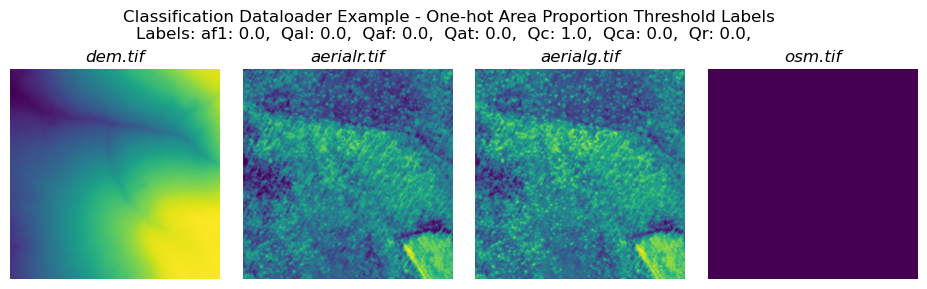

In [50]:
########################################################
# Classification DataLoader Example - WITH THRESHOLD
########################################################


##### pre-processing...
# extract total number of channels to plot...
num_channels = len(input_dict['multi']['channels'])

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1


##### plot figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
fig.subplots_adjust(wspace=0)
ax = ax.ravel()

# plot input features...
idx = 0
for k,v in cls_example.items():
    if 'label' in k:
        labels = v.detach().numpy()[0]
        labels = [(round(i.item(), 2)) for i in labels]
        label = ''
        for n, oh in zip(list(SG_MAPPING.keys()), labels):
            label += f"{n}: {oh},  "
        fig.suptitle(f"Classification Dataloader Example - One-hot Area Proportion Threshold Labels\nLabels: {label}")
    
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(input_dict['multi']['channels'][idx], style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()

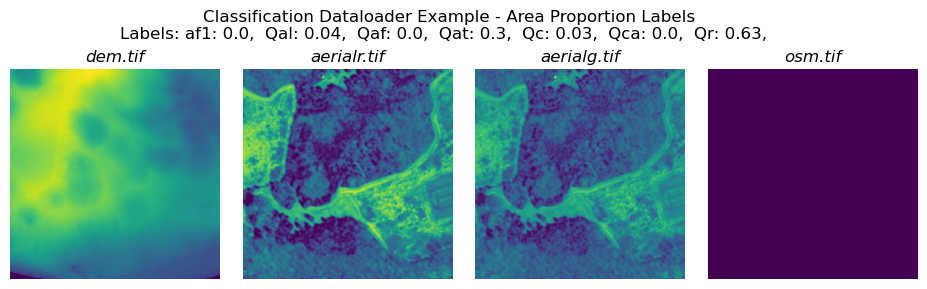

In [51]:
########################################################
# Classification DataLoader Example - NO THRESHOLD
########################################################


##### pre-processing...
# extract total number of channels to plot...
num_channels = len(input_dict['multi']['channels'])

# define number of columns & rows...
ncols = min(4, num_channels)
nrows = (num_channels // ncols) + 1


##### plot figure...
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))
fig.subplots_adjust(wspace=0)
ax = ax.ravel()

# plot input features...
idx = 0
for k,v in thresh_example.items():
    if 'label' in k:
        labels = v.detach().numpy()[0]
        labels = [(round(i.item(), 2)) for i in labels]
        label = ''
        for n, oh in zip(list(SG_MAPPING.keys()), labels):
            label += f"{n}: {oh},  "
        fig.suptitle(f"Classification Dataloader Example - Area Proportion Labels\nLabels: {label}")
    
    else:
        v_sample = v.detach().numpy()[0]
        for c in range(v_sample.shape[0]):
            img = v_sample[c]
            min_val = img.min()
            max_val = img.max()
            img = (img - min_val) / (max_val - min_val + 1e-8)
            ax[idx].imshow(img)
            ax[idx].set_axis_off()
            ax[idx].set_title(input_dict['multi']['channels'][idx], style='italic')
            idx += 1

# remove any extra subplot axes...
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.show()

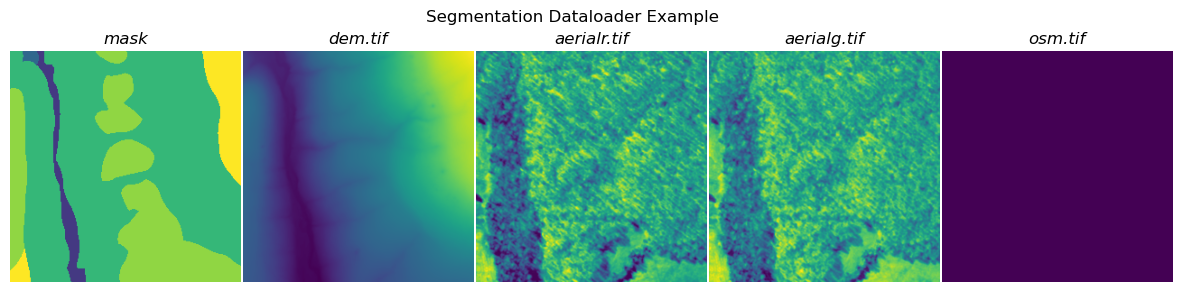

In [66]:
########################################################
# Segmentation DataLoader Example
########################################################


##### pre-processing...
# extract total number of channels to plot...
num_channels = len(input_dict['multi']['channels'])

# define number of columns & rows...
ncols = num_channels + 1

# first sample in batch to plot
mask = seg_example['mask'][0].detach().cpu().numpy() # (H, W)
x = seg_example['multi'][0].detach().cpu().numpy()   # (C, H, W)


##### plot figure...
fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(3*ncols, 3))
fig.subplots_adjust(wspace=0.01)
ax = ax.ravel()

# plot mask...
ax[0].imshow(mask, vmin=0, vmax=6)
ax[0].set_title('mask', style='italic')
ax[0].set_axis_off()

# plot input channels...
for c in range(num_channels):
    img = x[c]
    min_val = img.min()
    max_val = img.max()
    img_disp = (img - min_val) / (max_val - min_val + 1e-8)
    ax[c + 1].imshow(img_disp)
    ax[c + 1].set_axis_off()
    ax[c + 1].set_title(input_dict['multi']['channels'][c], style='italic')

# remove any extra subplot axes...
idx = num_channels + 1
for j in range(idx, len(ax)):
    fig.delaxes(ax[j])

plt.suptitle('Segmentation Dataloader Example', y=1.02)

plt.show()